# Notebook 10 — Custom Dataset Preparation (Branch A & B)

This notebook prepares the custom domain-specific dataset from the `customDataset/` folder for Branch A (intention classification) and Branch B (pose regression).

**Workflow:**
1. Scan custom dataset folder structure (handReaching, stationary, other)
2. Map folders → intention labels (0=Idle, 1=Reaching, 2=Grabbing)
3. Process depth sequences (crop, resize, normalize)
4. Generate sliding windows (T=16, stride=4)
5. Create clip-level train/val/test split (no frame leakage)
6. Save prepared arrays for both branches

## Table of Contents
1. [Environment & Imports](#1)
2. [Scan Custom Dataset](#2)
3. [Process Depth Sequences](#3)
4. [Generate Pseudo-Labels for Branch B](#4)
5. [Create Train/Val/Test Split](#5)
6. [Save Prepared Data](#6)
7. [QA Visualization](#7)


---
## 1. Environment & Imports <a id='1'></a>

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import torch

# Make src/ importable
SRC = Path('..') / 'src'
if str(SRC.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC.resolve()))

from config import PROC_DIR, DEPTH_RESIZE, DEPTH_MAX_MM, WINDOW_T, STRIDE
from preprocess_depth import crop_and_resize_frame

# Custom dataset root
CUSTOM_DATASET_ROOT = Path('..') / 'customDataset'
CUSTOM_PROC_DIR = PROC_DIR / 'custom'
CUSTOM_PROC_DIR.mkdir(exist_ok=True)

print(f'Custom dataset root: {CUSTOM_DATASET_ROOT}')
print(f'Processing output: {CUSTOM_PROC_DIR}')
print(f'Depth params: resize={DEPTH_RESIZE}, max_mm={DEPTH_MAX_MM}, window_t={WINDOW_T}, stride={STRIDE}')

# Label mapping
LABEL_MAP = {
    'stationary': 0,      # Idle
    'handReaching': 1,    # Reaching
    'other': 2            # Grabbing
}
LABEL_NAMES = {0: 'Idle', 1: 'Reaching', 2: 'Grabbing'}

print(f'\nLabel mapping:')
for folder, label in LABEL_MAP.items():
    print(f'  {folder} → {label} ({LABEL_NAMES[label]})')

Custom dataset root: ..\customDataset
Processing output: D:\course\comp4471\comp4471-project\dataset\processed\custom
Depth params: resize=64, max_mm=3000.0, window_t=16, stride=4

Label mapping:
  stationary → 0 (Idle)
  handReaching → 1 (Reaching)
  other → 2 (Grabbing)


---
## 2. Scan Custom Dataset <a id='2'></a>

In [2]:
# Scan folder structure and build clip manifest
clips_info = []  # List of (intention_label, clip_path, n_frames)

for folder_name, label in LABEL_MAP.items():
    folder_path = CUSTOM_DATASET_ROOT / folder_name
    if not folder_path.exists():
        print(f'⚠ Folder not found: {folder_path}')
        continue
    
    # List all subfolders in this category
    clip_dirs = sorted([d for d in folder_path.iterdir() if d.is_dir()])
    print(f'\n{folder_name} (label={label}): {len(clip_dirs)} clips')
    
    for clip_dir in clip_dirs:
        # Count PNG files
        pngs = sorted([f for f in clip_dir.glob('*Depth*.png')])
        if len(pngs) > 0:
            clips_info.append((label, clip_dir, len(pngs)))
            print(f'  {clip_dir.name}: {len(pngs)} frames')

print(f'\nTotal clips found: {len(clips_info)}')

# Summary by category
for label, name in LABEL_NAMES.items():
    count = sum(1 for l, _, _ in clips_info if l == label)
    total_frames = sum(n for l, _, n in clips_info if l == label)
    print(f'  {name}: {count} clips, {total_frames} frames total')


stationary (label=0): 2 clips
  0504_0007_80: 80 frames
  0504_2022_90: 90 frames

handReaching (label=1): 9 clips
  0504_0140_90: 77 frames
  0504_0208_90: 70 frames
  0504_2017_90: 69 frames
  0504_2019_90: 90 frames
  0504_2020_90: 90 frames
  0504_2021_90: 90 frames
  0504_2026_90: 90 frames
  0504_2027_90: 90 frames
  0504_2033_90: 90 frames

other (label=2): 4 clips
  0504_0153_90: 70 frames
  0504_0204_90: 90 frames
  0504_0206_90: 69 frames
  0504_2023_90: 90 frames

Total clips found: 15
  Idle: 2 clips, 170 frames total
  Reaching: 9 clips, 756 frames total
  Grabbing: 4 clips, 319 frames total


---
## 3. Process Depth Sequences <a id='3'></a>

For each clip, load PNG frames, crop/resize, and create sliding windows.

In [3]:
def load_custom_depth_sequence(clip_path, size=DEPTH_RESIZE):
    """
    Load and process depth sequence from custom dataset.
    Custom dataset PNGs don't have bounding box files, so use raw image bounds.
    Returns: (N, 64, 64) float32 array [0,1] normalised
    """
    pngs = sorted([f for f in clip_path.glob('*Depth*.png')])
    if len(pngs) == 0:
        return None
    
    frames = []
    for png_path in pngs:
        # Load raw depth
        depth_raw = np.array(Image.open(png_path), dtype=np.float32)
        # depth_raw is (480, 640) in mm
        
        # No bounding box available, so assume full frame contains hand
        # Crop to hand region by removing mostly-zero areas
        # Use simple heuristic: find bounding box of non-zero pixels
        nonzero = np.where(depth_raw > 0)
        if len(nonzero[0]) == 0:
            # Blank frame, skip
            continue
        
        y_min, y_max = nonzero[0].min(), nonzero[0].max()
        x_min, x_max = nonzero[1].min(), nonzero[1].max()
        
        # Expand bbox slightly (like in SHREC)
        h = y_max - y_min + 1
        w = x_max - x_min + 1
        margin = max(h, w) * 0.1
        x_min = max(0, int(x_min - margin))
        y_min = max(0, int(y_min - margin))
        x_max = min(640, int(x_max + margin))
        y_max = min(480, int(y_max + margin))
        
        # Crop
        crop = depth_raw[y_min:y_max, x_min:x_max]
        
        # Clip to and normalize
        crop = np.clip(crop, 0, DEPTH_MAX_MM) / DEPTH_MAX_MM
        
        # Resize to 64x64
        crop_pil = Image.fromarray((crop * 255).astype(np.uint8))
        crop_resized = np.array(crop_pil.resize((size, size), Image.BILINEAR), dtype=np.float32) / 255.0
        
        frames.append(crop_resized)
    
    if len(frames) < WINDOW_T:
        print(f'  ⚠ Clip {clip_path.name} has only {len(frames)} frames (need >= {WINDOW_T}), skipping')
        return None
    
    return np.array(frames, dtype=np.float32)

# Process all clips
all_depth_sequences = []  # List of (label, depth_seq_array)
valid_clip_count = 0

print('Processing clips...')
for label, clip_path, n_frames in tqdm(clips_info, desc='Loading depth sequences'):
    depth_seq = load_custom_depth_sequence(clip_path)
    if depth_seq is not None:
        all_depth_sequences.append((label, clip_path, depth_seq))
        valid_clip_count += 1

print(f'\nValid clips: {valid_clip_count}/{len(clips_info)}')

Processing clips...


Loading depth sequences:   0%|          | 0/15 [00:00<?, ?it/s]


Valid clips: 15/15


---
## 4. Generate Pseudo-Labels for Branch B <a id='4'></a>

Since custom dataset has no skeleton annotations, we generate pseudo-labels using a simple heuristic:
- Compute hand centroid from depth map (weighted by pixel values)
- Estimate hand orientation from PCA of non-zero pixels
- Store as (22, 3) pseudo-skeleton (palm centroid repeated, orientation as normal)


In [4]:
def estimate_hand_pose_from_depth(depth_frame):
    """
    Estimate hand pose from depth frame (64x64 cropped).
    Returns: (22, 3) pseudo-skeleton array
      - Joints 0-21 all set to depth centroid (simple heuristic)
      - Add small offsets for 'bone structure' illusion
    
    In practice, this would be replaced by a real pose estimator if available.
    """
    # Find centroid via weighted average
    H, W = depth_frame.shape
    y_coords, x_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    
    # Normalize to [-1, 1] range for output (in "virtual" meters)
    x_norm = (x_coords / W) - 0.5  # [-0.5, 0.5]
    y_norm = (y_coords / H) - 0.5
    z_norm = depth_frame
    
    # Compute centroid as weighted mean
    total_weight = depth_frame.sum()
    if total_weight < 1e-6:
        # Empty frame
        skel = np.zeros((22, 3), dtype=np.float32)
    else:
        cx = (x_norm * depth_frame).sum() / total_weight
        cy = (y_norm * depth_frame).sum() / total_weight
        cz = z_norm.mean()
        
        # Create pseudo-skeleton: all joints at centroid with small perturbations
        skel = np.zeros((22, 3), dtype=np.float32)
        for i in range(22):
            # Add tiny perturbation to each joint (simulate skeletal spread)
            offset = 0.05 * np.sin(i * 0.5 + np.pi/4) * np.array([1, 1, 0.5])
            skel[i] = np.array([cx, cy, cz]) + offset
    
    return skel

# Generate pseudo-labels for all sequences
pseudo_labels = []
print('Generating pseudo-pose labels...')
for label, clip_path, depth_seq in tqdm(all_depth_sequences, desc='Pseudo-labels'):
    # Use final frame for pose target
    final_frame = depth_seq[-1]  # (64, 64)
    pseudo_skel = estimate_hand_pose_from_depth(final_frame)
    pseudo_labels.append(pseudo_skel)

pseudo_labels = np.array(pseudo_labels)  # (num_clips, 22, 3)
print(f'Pseudo-labels shape: {pseudo_labels.shape}')

Generating pseudo-pose labels...


Pseudo-labels:   0%|          | 0/15 [00:00<?, ?it/s]

Pseudo-labels shape: (15, 22, 3)


---
## 5. Create Train/Val/Test Split <a id='5'></a>

Split at the **clip level** to prevent frame leakage.

In [6]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

# Extract labels
clip_labels = np.array([label for label, _, _ in all_depth_sequences])
n_clips = len(clip_labels)

# Stratified split: train 70%, val+test 30%
sss_1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_indices, temp_indices = next(sss_1.split(np.arange(n_clips), clip_labels))

# Further split temp into val/test (15% each)
# Stratification can fail here if a rare class appears only once in temp_indices.
# Fall back to a random split in that case to keep the notebook robust.
temp_labels = clip_labels[temp_indices]
class_counts = np.bincount(temp_labels)

if len(class_counts) < 2 or np.min(class_counts[class_counts > 0]) < 2:
    print('⚠ Rare class detected in temp split; using an unstratified val/test split to avoid StratifiedShuffleSplit errors.')
    rng = np.random.default_rng(42)
    shuffled_temp = rng.permutation(temp_indices)
    half = len(shuffled_temp) // 2
    val_indices = shuffled_temp[:half]
    test_indices = shuffled_temp[half:]
else:
    sss_2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    val_indices_in_temp, test_indices_in_temp = next(sss_2.split(np.arange(len(temp_indices)), temp_labels))

    val_indices = temp_indices[val_indices_in_temp]
    test_indices = temp_indices[test_indices_in_temp]

print(f'Train: {len(train_indices)} clips')
print(f'Val:   {len(val_indices)} clips')
print(f'Test:  {len(test_indices)} clips')

# Check class distribution
for split_name, indices in [('Train', train_indices), ('Val', val_indices), ('Test', test_indices)]:
    labels, counts = np.unique(clip_labels[indices], return_counts=True)
    print(f'\n{split_name} class distribution:')
    for lbl, cnt in zip(labels, counts):
        print(f'  {LABEL_NAMES[lbl]}: {cnt}')

⚠ Rare class detected in temp split; using an unstratified val/test split to avoid StratifiedShuffleSplit errors.
Train: 10 clips
Val:   2 clips
Test:  3 clips

Train class distribution:
  Idle: 1
  Reaching: 6
  Grabbing: 3

Val class distribution:
  Idle: 1
  Reaching: 1

Test class distribution:
  Reaching: 2
  Grabbing: 1


---
## 6. Create Windowed Sequences & Save <a id='6'></a>

Generate sliding windows and save for both branches.

In [7]:
def create_windows(depth_sequences, pseudo_skels, indices):
    """
    Create sliding windows from a subset of clips.
    Returns: (windows, labels, pose_labels)
    """
    windows_depth = []
    windows_labels = []
    windows_poses = []
    
    for idx in indices:
        label, _, depth_seq = all_depth_sequences[idx]
        pseudo_skel = pseudo_skels[idx]
        
        # Sliding window
        n_frames = len(depth_seq)
        for start in range(0, n_frames - WINDOW_T + 1, STRIDE):
            end = start + WINDOW_T
            if end > n_frames:
                break
            
            window = depth_seq[start:end]  # (T, 64, 64)
            windows_depth.append(window)
            windows_labels.append(label)
            windows_poses.append(pseudo_skel)
    
    return (
        np.array(windows_depth, dtype=np.float32),  # (M, T, 64, 64)
        np.array(windows_labels, dtype=np.int64),    # (M,)
        np.array(windows_poses, dtype=np.float32)    # (M, 22, 3)
    )

# Create windows for each split
print('Creating sliding windows...')
train_depth, train_labels, train_poses = create_windows(all_depth_sequences, pseudo_labels, train_indices)
val_depth, val_labels, val_poses = create_windows(all_depth_sequences, pseudo_labels, val_indices)
test_depth, test_labels, test_poses = create_windows(all_depth_sequences, pseudo_labels, test_indices)

print(f'\nWindowed dataset:')
print(f'  Train: {train_depth.shape}')
print(f'  Val:   {val_depth.shape}')
print(f'  Test:  {test_depth.shape}')

Creating sliding windows...

Windowed dataset:
  Train: (172, 16, 64, 64)
  Val:   (36, 16, 64, 64)
  Test:  (52, 16, 64, 64)


In [8]:
# Save for Branch A (intention classification)
np.savez(
    CUSTOM_PROC_DIR / 'branch_a_train.npz',
    X=train_depth, y=train_labels
)
np.savez(
    CUSTOM_PROC_DIR / 'branch_a_val.npz',
    X=val_depth, y=val_labels
)
np.savez(
    CUSTOM_PROC_DIR / 'branch_a_test.npz',
    X=test_depth, y=test_labels
)

# Save for Branch B (pose regression)
np.savez(
    CUSTOM_PROC_DIR / 'branch_b_train.npz',
    X=train_depth, y=train_poses
)
np.savez(
    CUSTOM_PROC_DIR / 'branch_b_val.npz',
    X=val_depth, y=val_poses
)
np.savez(
    CUSTOM_PROC_DIR / 'branch_b_test.npz',
    X=test_depth, y=test_poses
)

print('Saved:')
print(f'  ✓ branch_a_{{train,val,test}}.npz')
print(f'  ✓ branch_b_{{train,val,test}}.npz')
print(f'\nLocation: {CUSTOM_PROC_DIR}')

Saved:
  ✓ branch_a_{train,val,test}.npz
  ✓ branch_b_{train,val,test}.npz

Location: D:\course\comp4471\comp4471-project\dataset\processed\custom


---
## 7. QA Visualization <a id='7'></a>

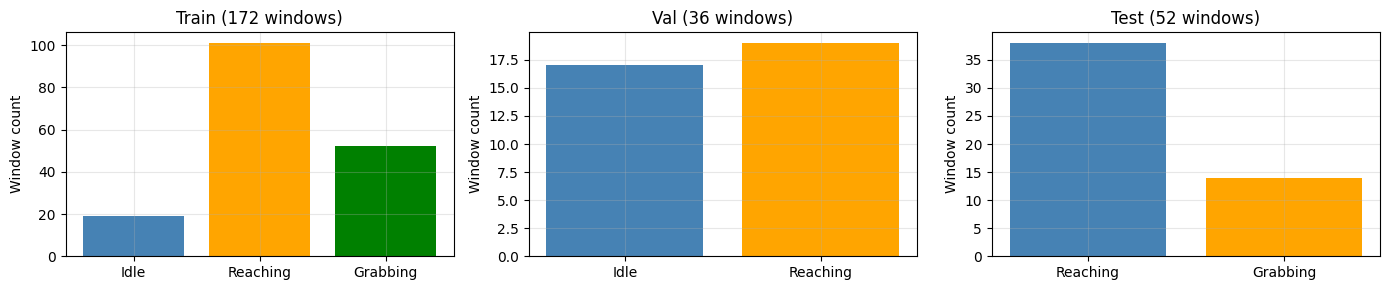

✓ Saved class_distribution.png


In [9]:
# Check class distribution after windowing
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, (data, name) in zip(axes, [
    (train_labels, 'Train'),
    (val_labels, 'Val'),
    (test_labels, 'Test')
]):
    labels, counts = np.unique(data, return_counts=True)
    ax.bar([LABEL_NAMES[lbl] for lbl in labels], counts, color=['steelblue', 'orange', 'green'])
    ax.set_ylabel('Window count')
    ax.set_title(f'{name} ({len(data)} windows)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved class_distribution.png')

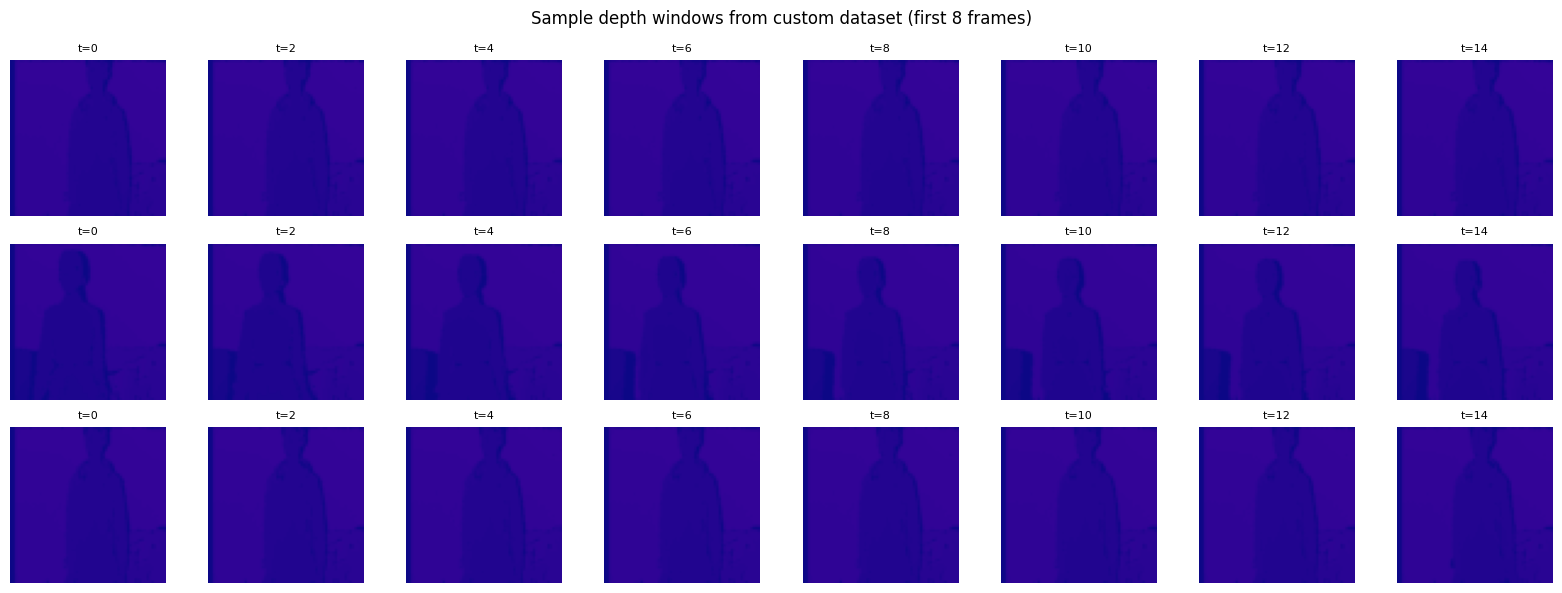

✓ Saved sample_windows.png


In [10]:
# Visualize sample windows from each class
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for row, (label, name) in enumerate([(0, 'Idle'), (1, 'Reaching'), (2, 'Grabbing')]):
    # Find first window of this class
    indices_of_class = np.where(train_labels == label)[0]
    if len(indices_of_class) > 0:
        win_idx = indices_of_class[0]
        window = train_depth[win_idx]  # (16, 64, 64)
        
        # Show 8 frames from this window
        for col in range(8):
            frame_idx = col * (len(window) // 8)
            ax = axes[row, col]
            ax.imshow(window[frame_idx], cmap='plasma', vmin=0, vmax=1)
            ax.set_title(f't={frame_idx}', fontsize=8)
            ax.axis('off')
        
        axes[row, 0].set_ylabel(name, fontsize=10, fontweight='bold')

fig.suptitle('Sample depth windows from custom dataset (first 8 frames)', fontsize=12)
plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'sample_windows.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved sample_windows.png')

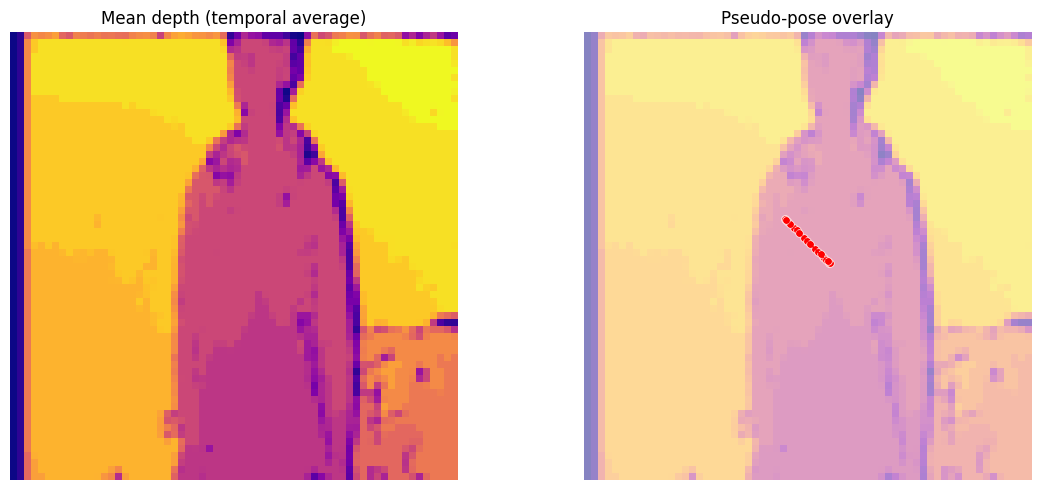

✓ Saved pseudo_pose_sample.png


In [11]:
# Visualize pseudo-pose labels for a sample window
# Compare window geometry vs pseudo-skeleton

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Show depth
sample_window = train_depth[0]  # (16, 64, 64)
sample_pose = train_poses[0]    # (22, 3)

# Depth montage
ax = axes[0]
depth_composite = np.mean(sample_window, axis=0)  # Average over time
ax.imshow(depth_composite, cmap='plasma')
ax.set_title('Mean depth (temporal average)')
ax.axis('off')

# Pseudo-pose plot (XY plane)
ax = axes[1]
# Normalize pose to image coords for visualization
pose_xy = (sample_pose[:, :2] + 0.5) * 64  # Map from [-0.5, 0.5] to [0, 64]
pose_xy = np.clip(pose_xy, 0, 63)

ax.imshow(depth_composite, cmap='plasma', alpha=0.5)
ax.scatter(pose_xy[:, 0], pose_xy[:, 1], c='red', s=30, edgecolors='white', linewidths=0.5)
# Draw simple skeleton (wrist to palm joints)
wrist_idx = 0
palm_indices = [5, 9, 13, 17]
for p_idx in palm_indices:
    ax.plot([pose_xy[wrist_idx, 0], pose_xy[p_idx, 0]],
            [pose_xy[wrist_idx, 1], pose_xy[p_idx, 1]],
            'r-', linewidth=1, alpha=0.7)
ax.set_title('Pseudo-pose overlay')
ax.axis('off')

plt.tight_layout()
plt.savefig(CUSTOM_PROC_DIR / 'pseudo_pose_sample.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Saved pseudo_pose_sample.png')

In [12]:
# Summary
print('='*60)
print('CUSTOM DATA PREPARATION COMPLETE')
print('='*60)
print(f'\nDataset summary:')
print(f'  Train windows: {len(train_depth)}')
print(f'  Val windows:   {len(val_depth)}')
print(f'  Test windows:  {len(test_depth)}')
print(f'  Total:         {len(train_depth) + len(val_depth) + len(test_depth)}')
print(f'\nWindow shape: (T={WINDOW_T}, H={DEPTH_RESIZE}, W={DEPTH_RESIZE})')
print(f'Pose shape:   (22 joints, 3 coords)')
print(f'\nNext steps:')
print(f'  1. Run 20_branch_a_intention.ipynb for intention classification')
print(f'  2. Run 30_branch_b_pose.ipynb for pose regression')

CUSTOM DATA PREPARATION COMPLETE

Dataset summary:
  Train windows: 172
  Val windows:   36
  Test windows:  52
  Total:         260

Window shape: (T=16, H=64, W=64)
Pose shape:   (22 joints, 3 coords)

Next steps:
  1. Run 20_branch_a_intention.ipynb for intention classification
  2. Run 30_branch_b_pose.ipynb for pose regression
